# List 2
## Author: Jan Pułtorak

In [25]:
import torch
import numpy as np
import random
import sklearn
from tqdm import tqdm
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed);

## Task 1

In [76]:
def mse(y_pred: torch.Tensor, y: torch.Tensor):
    n = y.shape[0]
    return torch.sum((y-y_pred)**2) / n

class Dataset:
    def __init__(self, X: torch.Tensor, y: torch.Tensor, split_ratio=0.8):

        indices = torch.randperm(len(X))
        X = X[indices]
        y = y[indices]

        m_train = int(len(X)*split_ratio)

        self.X_train = X[:m_train]
        self.y_train = y[:m_train]
        self.X_test = X[m_train:]
        self.y_test = y[m_train:]

        self.mean = self.X_train.mean(dim=0)
        self.std = self.X_train.std(dim=0)

        self.X_train = self.normalize(self.X_train, self.mean, self.std)
        self.X_test = self.normalize(self.X_test, self.mean, self.std)

    @staticmethod
    def normalize(X: torch.Tensor, mean, std):
        return (X - mean)/std


class Model:
    def __init__(self, d):
        self.W = torch.randn((d, 1), requires_grad=True)
        self.b = torch.randn(1, requires_grad=True)

    def forward(self, X: torch.Tensor):
        return X @ self.W + self.b

    def zero_grad(self):
        if self.W.grad is not None:
            self.W.grad.zero_()
        if self.b.grad is not None:
            self.b.grad.zero_()

    def train(self, data: Dataset, learning_rate, epochs=200):

        train_losses = []
        test_losses = []
        grad_norms = []

        X_train, y_train = data.X_train, data.y_train
        X_test, y_test = data.X_test, data.y_test

        for _ in tqdm(range(epochs), desc="Training"):
            y_pred = self.forward(X_train)
            loss = mse(y_pred, y_train)

            with torch.no_grad():
                y_pred_val = self.forward(X_test)
                test_loss = mse(y_pred_val, y_test)

            loss.backward()

            grad_norm = torch.norm(self.W.grad, p=2).item()
            grad_norms.append(grad_norm)

            with torch.no_grad():
                self.W -= learning_rate * self.W.grad
                self.b -= learning_rate * self.b.grad
                self.zero_grad()

            train_losses.append(loss.item())
            test_losses.append(test_loss.item())

        return train_losses, test_losses, grad_norms


In [77]:
dataset = sklearn.datasets.fetch_california_housing()

X = torch.tensor(dataset.data).float()
y = torch.tensor(dataset.target, dtype=torch.float32).unsqueeze(dim=1)
print(X.shape, y.shape)

data = Dataset(X, y)

torch.Size([20640, 8]) torch.Size([20640, 1])


In [59]:
model =  Model(X.size(dim=1))
train_losses, test_losses = model.train(data, learning_rate=0.3)

Training: 100%|██████████| 200/200 [00:00<00:00, 6140.28it/s]


In [60]:
print(test_losses[:5], train_losses[:5])

[10.999629020690918, 2.0561647415161133, 0.8244425654411316, 0.6250767707824707, 0.5867555141448975] [9.307950019836426, 1.636881709098816, 0.7422776222229004, 0.6028709411621094, 0.5758934617042542]


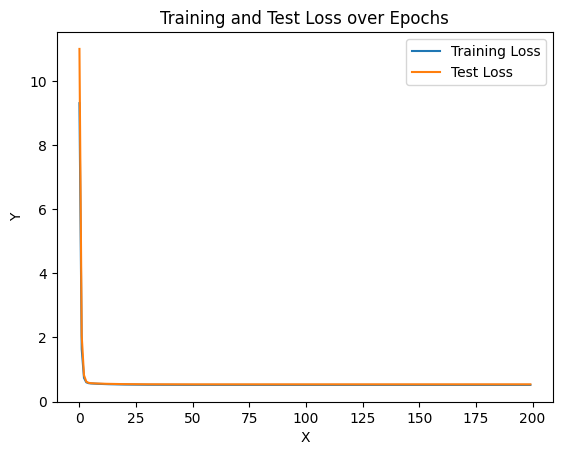

In [65]:
fig, ax = plt.subplots()
ax.plot(train_losses, label="Training Loss")
ax.plot(test_losses, label="Test Loss")
ax.set(xlabel='X', ylabel='Y', title="Training and Test Loss over Epochs")
ax.legend()


## Task 2

In [68]:
ones_train = torch.ones((data.X_train.shape[0], 1))
ones_test = torch.ones((data.X_test.shape[0], 1))

X_train = torch.cat((data.X_train, ones_train), dim=1)
X_test = torch.cat((data.X_test, ones_test), dim=1)

A = X_train.T @ X_train
B = X_train.T @ data.y_train
W_opt = torch.linalg.solve(A, B)

In [74]:
mse_train_cf = mse(X_train @ W_opt, data.y_train)
mse_test_cf =  mse(X_test @ W_opt, data.y_test)

with torch.no_grad():
    mse_train_grad = mse(model.forward(data.X_train), data.y_train)
    mse_test_grad = mse(model.forward(data.X_test), data.y_test)

print("Train: ", mse_train_cf, mse_train_grad)
print("Test: ", mse_test_cf, mse_test_grad)

Train:  tensor(0.5208) tensor(0.5208)
Test:  tensor(0.5393) tensor(0.5393)


## Task 3

In [91]:
learning_rates = {"Small": 0.001, "Medium": 0.1, "Large": 1.5}
results = {}

for label, lr in learning_rates.items():
    model = Model(X.size(dim=1))
    train_loss, test_loss, grad_norms = model.train(data, learning_rate=lr)
    results[label] = {"train": train_loss, "test": test_loss, "grad": grad_norms}


Training: 100%|██████████| 200/200 [00:00<00:00, 7940.60it/s]


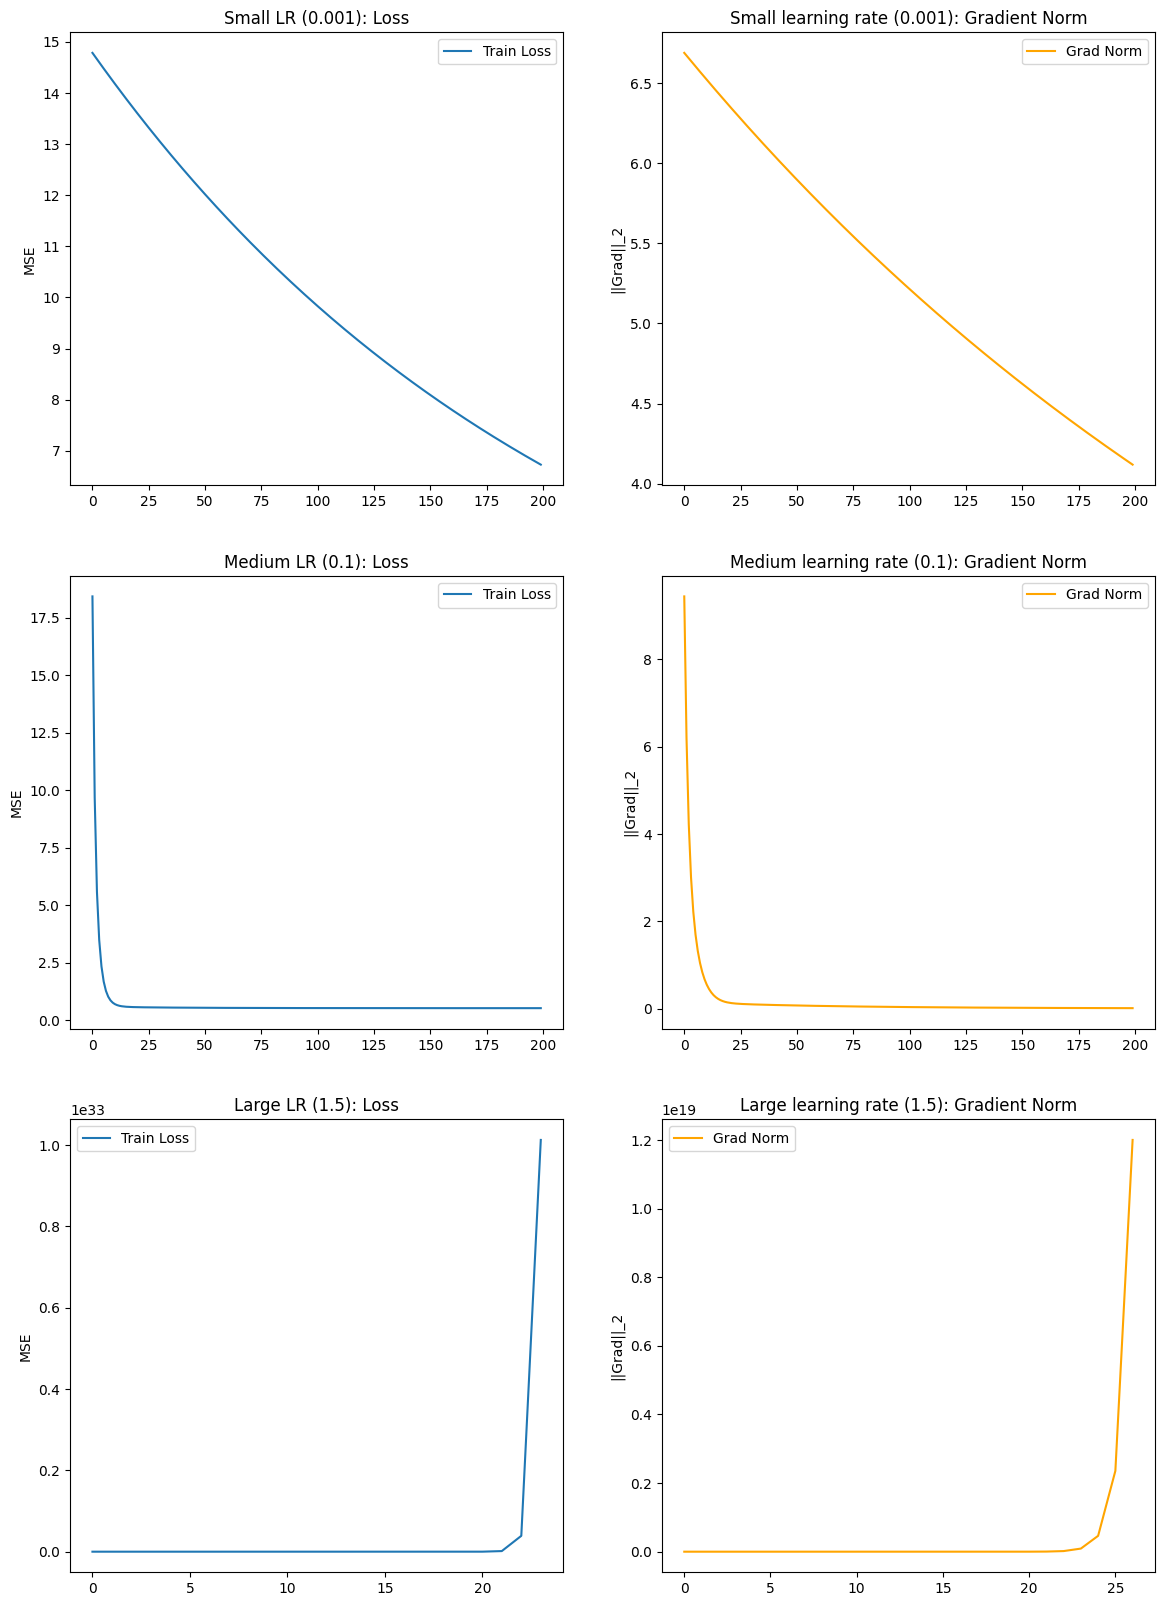

In [92]:
fig, axes = plt.subplots(3, 2, figsize=(14, 20))

for i, (label, metrics) in enumerate(results.items()):
    lr = learning_rates[label]

    axes[i, 0].plot(metrics["train"], label='Train Loss')
    axes[i, 0].set_title(f"{label} LR ({lr}): Loss")
    axes[i, 0].set_ylabel("MSE")
    axes[i, 0].legend()

    axes[i, 1].plot(metrics["grad"], label='Grad Norm', color='orange')
    axes[i, 1].set_title(f"{label} learning rate ({lr}): Gradient Norm")
    axes[i, 1].set_ylabel("||Grad||_2")
    axes[i, 1].legend()